# Variant set plot — development tutorial

This notebook demonstrates the in-development **`gl.SumstatsSet`** + **`plot_effect()`** workflow for comparing effect sizes of a fixed variant list across multiple GWAS studies.

**What it does**

1. Load two or more `Sumstats` objects (or auto-load via glob pattern)
2. Extract rows matching `variant_set` (rsID, `[CHR, POS]`, or `chr:pos:ea:nea` strings)
3. Plot a forest-style figure grouped by variant, with optional **EAF** and **SNPR2** (per-variant R²) side panels

**Related (different) APIs**

- `gl.compare_effect()` — scatter for **two** studies
- `gl.plot_forest()` — meta-analysis forest with combined estimate

Published tutorial: `docs/visualization_variant_set.md`

In [14]:
import os
import sys
import tempfile
import shutil

import pandas as pd

_candidates = [
    os.path.join(os.getcwd(), "..", "..", ".."),
    os.path.join(os.getcwd(), "..", ".."),
    os.path.join(os.getcwd()),
]
ROOT = next(
    os.path.abspath(c)
    for c in _candidates
    if os.path.isdir(os.path.join(os.path.abspath(c), "src", "gwaslab"))
)
SRC = os.path.join(ROOT, "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import gwaslab as gl
print("ROOT:", ROOT)

ROOT: /home/yunye/work/gwaslab


## Synthetic example (no downloads)

Three small studies share variants at `1:100`, `2:200`, and `rs7890`.

In [15]:
rows_a = [
    {"CHR": 1, "POS": 100, "EA": "A", "NEA": "G", "BETA": 0.10, "SE": 0.02, "P": 1e-6, "EAF": 0.35, "SNPID": "1:100:A:G"},
    {"CHR": 2, "POS": 200, "EA": "C", "NEA": "T", "BETA": -0.05, "SE": 0.03, "P": 1e-4, "EAF": 0.22, "SNPID": "2:200:C:T"},
    {"CHR": 7, "POS": 500000, "EA": "G", "NEA": "A", "BETA": 0.15, "SE": 0.025, "P": 1e-8, "EAF": 0.18, "SNPID": "rs7890"},
]
rows_b = [
    {"CHR": 1, "POS": 100, "EA": "A", "NEA": "G", "BETA": 0.08, "SE": 0.02, "P": 5e-8, "EAF": 0.33, "SNPID": "1:100:A:G"},
    {"CHR": 7, "POS": 500000, "EA": "G", "NEA": "A", "BETA": 0.12, "SE": 0.03, "P": 1e-6, "EAF": 0.20, "SNPID": "rs7890"},
]
rows_c = [
    {"CHR": 1, "POS": 100, "EA": "A", "NEA": "G", "BETA": 0.06, "SE": 0.025, "P": 1e-4, "EAF": 0.30, "SNPID": "1:100:A:G"},
    {"CHR": 7, "POS": 500000, "EA": "G", "NEA": "A", "BETA": 0.09, "SE": 0.028, "P": 1e-5, "EAF": 0.16, "SNPID": "rs7890"},
]

def make_sumstats(rows):
    return gl.Sumstats(
        sumstats=pd.DataFrame(rows),
        chrom="CHR", pos="POS", ea="EA", nea="NEA",
        snpid="SNPID", beta="BETA", se="SE", p="P", eaf="EAF",
        verbose=False,
    )

studies = {
    "StudyA": make_sumstats(rows_a),
    "StudyB": make_sumstats(rows_b),
    "StudyC": make_sumstats(rows_c),
}

## Build `SumstatsSet` and inspect extracted rows

Mixed variant ID formats: coordinate pair, variant string, and rsID.

In [16]:
variant_set = [[1, 100], "2:200:C:T", "rs7890"]

sset = gl.SumstatsSet(studies, variant_set=variant_set, verbose=True)
sset.data[["STUDY", "SNPID", "CHR", "POS", "BETA", "SE", "EAF"]]

2026/07/07 13:12:52 GWASLab v4.2.0 https://cloufield.github.io/gwaslab/
2026/07/07 13:12:52 (C) 2022-2026, Yunye He, Kamatani Lab, GPL-3.0 license, gwaslab@gmail.com
2026/07/07 13:12:52 Python version: 3.12.0 | packaged by conda-forge | (main, Oct  3 2023, 08:43:22) [GCC 12.3.0]
2026/07/07 13:12:52 Start to initialize gl.SumstatsSet ...(v4.2.0)
2026/07/07 13:12:52  -StudyA : <gwaslab.g_Sumstats.Sumstats object at 0x7ee47b5d32c0>
2026/07/07 13:12:52  -StudyB : <gwaslab.g_Sumstats.Sumstats object at 0x7ee4ea1e29c0>
2026/07/07 13:12:52  -StudyC : <gwaslab.g_Sumstats.Sumstats object at 0x7ee487321f10>
2026/07/07 13:12:52  -Extracted 3 variants from StudyA
2026/07/07 13:12:52  -Extracted 2 variants from StudyB
2026/07/07 13:12:52  -Extracted 2 variants from StudyC
2026/07/07 13:12:52  -Time taken: 0.009s
2026/07/07 13:12:52 Finished initializing gl.SumstatsSet.


,STUDY,SNPID,CHR,POS,BETA,SE,EAF
0,StudyA,1:100:A:G,1,100,0.10,0.020,0.35
1,StudyA,2:200:C:T,2,200,-0.05,0.030,0.22
2,StudyA,rs7890,7,500000,0.15,0.025,0.18
3,StudyB,1:100:A:G,1,100,0.08,0.020,0.33
4,StudyB,rs7890,7,500000,0.12,0.030,0.20
5,StudyC,1:100:A:G,1,100,0.06,0.025,0.30
6,StudyC,rs7890,7,500000,0.09,0.028,0.16


## How SNPR2 is calculated

`plot_effect()` shows an **SNPR2** side panel when the column exists. Use `get_per_snp_r2()` to compute it. Full API: `docs/PerSNPh2.md`.

### Quantitative traits (`mode="q"`)

Additive model \(Y = \beta X + \varepsilon\), Hardy–Weinberg, dosage \(X \in \{0,1,2\}\):

- \(\mathrm{Var}(X) = 2 \cdot \mathrm{EAF} \cdot (1 - \mathrm{EAF})\)
- \(\mathrm{Var}(\beta X) = 2 \cdot \beta^2 \cdot \mathrm{EAF} \cdot (1 - \mathrm{EAF})\)
- \(\mathrm{SNPR2} = \dfrac{\mathrm{Var}(\beta X)}{\mathrm{Var}(Y)} = \dfrac{2 \cdot \beta^2 \cdot \mathrm{EAF} \cdot (1 - \mathrm{EAF})}{\mathrm{Var}(Y)}\)

This notebook uses **`vary=1`**, so \(\mathrm{Var}(Y) = 1\) (standardized trait / SD-scaled **BETA**). Requires **BETA** and **EAF** only. This is **not** Shim S1 eq. (4); it uses the same numerator with unit Var(Y).

Alternative: **`vary="se"`** applies Shim et al. (2015) S1 **eq. (4)** when **SE** and **N** are available:

$$\mathrm{SNPR2} = \frac{2 \beta^2 \cdot \mathrm{EAF}(1-\mathrm{EAF})}{2 \beta^2 \cdot \mathrm{EAF}(1-\mathrm{EAF}) + \mathrm{SE}^2 \cdot 2N \cdot \mathrm{EAF}(1-\mathrm{EAF})}$$

Reference: [Shim et al. 2015 S1 Text](http://journals.plos.org/plosone/article/asset?id=info%3Adoi%2F10.1371%2Fjournal.pone.0120758.s001).

### Binary traits (`mode="b"`)

For case–control GWAS, **BETA** is **log(OR)** on the liability/log-odds scale. Also requires **`ncase`**, **`ncontrol`**, and population **`prevalence`**.

1. **Population EAF** (`_POPAF`): back-calculated from sample EAF, case proportion, OR = exp(BETA), and prevalence ([`population_allele_frequency()`](../../src/gwaslab/algorithm/core/h2.py))
2. **Genetic variance**: \(V_G = \beta^2 \cdot p(1-p)\) where \(p =\) `_POPAF` (note: no factor of 2, unlike quantitative)
3. **Liability-scale R²**: \(\mathrm{SNPR2} = \dfrac{V_G}{V_G + V_E}\) with \(V_E = \pi^2/3 \approx 3.29\)

References: [TwoSampleMR `get_r_from_lor()`](https://mrcieu.github.io/TwoSampleMR/reference/get_r_from_lor.html) (operational formula); Lee et al. (2012), *Genetic Epidemiology* — liability-scale R² framework ([doi:10.1002/gepi.21614](https://doi.org/10.1002/gepi.21614)).

### Comparison

| | **`mode="q"`** | **`mode="b"`** |
|--|----------------|----------------|
| **BETA** | Per-allele effect on **Y** | **log(OR)** |
| **Numerator** | \(2\beta^2 \cdot \mathrm{EAF}(1-\mathrm{EAF})\) | \(eta^2 \cdot p(1-p)\) |
| **Denominator** | \(\mathrm{Var}(Y)\) — `vary=1`, number, or `"se"` | \(V_G + \pi^2/3\) |
| **Extra inputs** | Optional **N**, **SE** for `vary="se"` | **ncase**, **ncontrol**, **prevalence** |

### Compute SNPR2 on the variant set (quantitative demo)

The cells below compute SNPR2 on the extracted `SumstatsSet` table, then verify the formula for one row.

In [17]:
sset.get_per_snp_r2(mode="q", vary=1, verbose=True)
sset.data[["STUDY", "SNPID", "BETA", "EAF", "SNPR2"]]

2026/07/07 13:12:52 Start to calculate per-SNP heritibility ...(v4.2.0)
2026/07/07 13:12:52  -Current Dataframe shape : 7 x 11 ; Memory usage: 0.00 MB
2026/07/07 13:12:52  -Calculating per-SNP rsq by 2 * (BETA**2) * AF * (1-AF) / Var(y)...
2026/07/07 13:12:52  -Var(y) is provided: 1...
2026/07/07 13:12:52 Finished calculating per-SNP heritability!
2026/07/07 13:12:52  -Current Dataframe shape : 7 x 13 ; Memory usage: 0.00 MB
2026/07/07 13:12:52  -Time taken: 0.002s
2026/07/07 13:12:52 Finished calculating per-SNP heritibility.


,STUDY,SNPID,BETA,EAF,SNPR2
0,StudyA,1:100:A:G,0.10,0.35,0.004550
1,StudyA,2:200:C:T,-0.05,0.22,0.000858
2,StudyA,rs7890,0.15,0.18,0.006642
3,StudyB,1:100:A:G,0.08,0.33,0.002830
4,StudyB,rs7890,0.12,0.20,0.004608
5,StudyC,1:100:A:G,0.06,0.30,0.001512
6,StudyC,rs7890,0.09,0.16,0.002177


In [18]:
# Verify quantitative formula (vary=1) matches get_per_snp_r2 for one row
row = sset.data.iloc[0]
manual = 2 * row["BETA"] ** 2 * row["EAF"] * (1 - row["EAF"]) / 1.0
print(f"Manual SNPR2:  {manual:.6f}")
print(f"gwaslab SNPR2: {row['SNPR2']:.6f}")

Manual SNPR2:  0.004550
gwaslab SNPR2: 0.004550


In [19]:
# Verify Shim S1 eq. (4): vary="se" (needs N column)
se_row = sset.data.iloc[0].copy()
se_row["N"] = 100000
manual_se = (
    2 * se_row["BETA"] ** 2 * se_row["EAF"] * (1 - se_row["EAF"])
    / (
        2 * se_row["BETA"] ** 2 * se_row["EAF"] * (1 - se_row["EAF"])
        + se_row["SE"] ** 2 * 2 * se_row["N"] * se_row["EAF"] * (1 - se_row["EAF"])
    )
)
se_df = se_row.to_frame().T
from gwaslab.util.util_in_convert_h2 import _get_per_snp_r2
se_df = _get_per_snp_r2(se_df, mode="q", vary="se", verbose=False)
print(f"Manual SNPR2 (vary=se):  {manual_se:.6f}")
print(f"gwaslab SNPR2 (vary=se): {se_df['SNPR2'].iloc[0]:.6f}")

Manual SNPR2 (vary=se):  0.000250
gwaslab SNPR2 (vary=se): 0.000250


### Binary trait example (`mode="b"`)

Illustrative standalone example (not part of the main `SumstatsSet` plot). Shows intermediate columns `_POPAF` and `_VG`.

In [20]:
binary_row = pd.DataFrame([{
    "SNPID": "rs999", "BETA": 0.20, "EAF": 0.15,  # BETA = log(OR)
}])
binary_ss = gl.Sumstats(
    sumstats=binary_row, snpid="SNPID", beta="BETA", eaf="EAF", verbose=False,
)
binary_ss.get_per_snp_r2(mode="b", ncase=5000, ncontrol=95000, prevalence=0.10, verbose=True)
binary_ss.data[["SNPID", "BETA", "EAF", "_POPAF", "_VG", "SNPR2"]]

2026/07/07 13:12:53 Start to calculate per-SNP heritibility ...(v4.2.0)
2026/07/07 13:12:53  -Current Dataframe shape : 1 x 4 ; Memory usage: 0.00 MB
2026/07/07 13:12:53 Finished calculating per-SNP heritability!
2026/07/07 13:12:53  -Current Dataframe shape : 1 x 10 ; Memory usage: 0.00 MB
2026/07/07 13:12:53  -Time taken: 0.003s
2026/07/07 13:12:53 Finished calculating per-SNP heritibility.


,SNPID,BETA,EAF,_POPAF,_VG,SNPR2
0,rs999,0.2,0.15,0.151356,0.005138,0.001559


## Plot effect sizes across studies

2026/07/07 13:12:53 Starting effect-size plot creation...
2026/07/07 13:12:53  -Input contains 7 variants.
2026/07/07 13:12:53 Configured plot style for plot_effect:None
2026/07/07 13:12:53  -Effect column: BETA, SE column: SE.
2026/07/07 13:12:53  -Y-axis label column: STUDY.
2026/07/07 13:12:53  -Grouping by: ['CHR', 'POS'].
2026/07/07 13:12:53  -Creating figure with 3 panel(s): effect+EAF+SNPR2.
2026/07/07 13:12:53  -Plotting effect panel with 7 variants...
2026/07/07 13:12:53  -Adding EAF panel.
2026/07/07 13:12:53  -Adding SNPR2 panel.
2026/07/07 13:12:53 Start to save figure...
2026/07/07 13:12:53  -Saved to /home/yunye/work/gwaslab/docs/images/notebooks/visualization_variant_set_basic.png successfully! (png) (overwrite)
2026/07/07 13:12:53 Finished saving figure...
2026/07/07 13:12:53 Finished effect-size plot successfully.


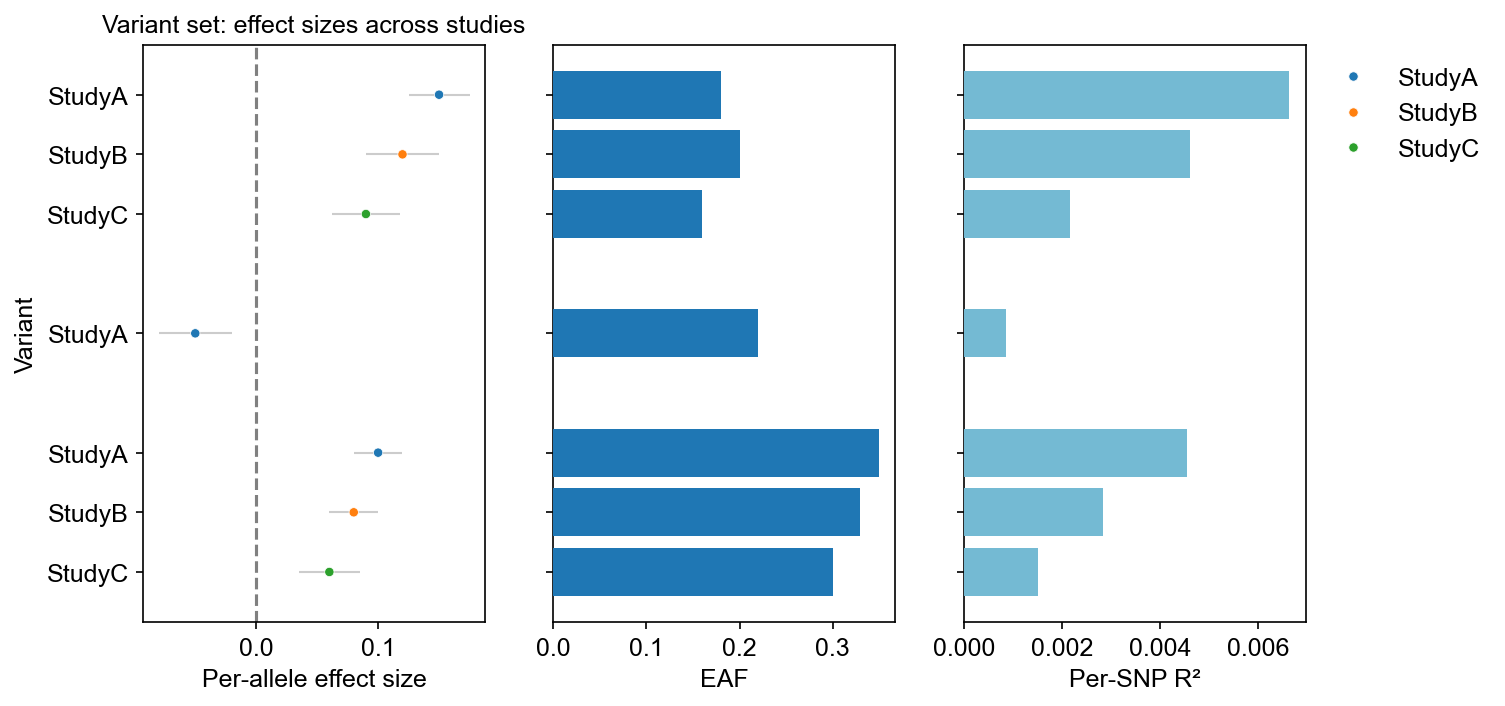

In [21]:
fig = sset.plot_effect(
    y="STUDY",
    group=["CHR", "POS"],
    y_sort=["CHR", "POS", "STUDY"],
    hue="STUDY",
    gap=1,
    title="Variant set: effect sizes across studies",
    effect_label="Per-allele effect size",
    eaf_panel=True,
    snpvar_panel=True,
    snpr2_label="Per-SNP R²",
    fig_kwargs={"figsize": (10, 5), "dpi": 150},
    save=os.path.join(ROOT, "docs", "images", "notebooks", "visualization_variant_set_basic.png"),
    verbose=True,
)

## Glob pattern loading

Write temporary cohort files and load them with a glob pattern. Study names are derived from filenames.

In [22]:
tmpdir = tempfile.mkdtemp()
try:
    pd.DataFrame(rows_a).to_csv(os.path.join(tmpdir, "cohort_EUR.txt"), sep="\t", index=False)
    pd.DataFrame(rows_b).to_csv(os.path.join(tmpdir, "cohort_EAS.txt"), sep="\t", index=False)

    pattern = os.path.join(tmpdir, "cohort_*.txt")
    sset_glob = gl.SumstatsSet(
        pattern,
        variant_set=["rs7890", [1, 100]],
        snpid="SNPID", chrom="CHR", pos="POS", ea="EA", nea="NEA",
        beta="BETA", se="SE", p="P", eaf="EAF",
        verbose=True,
    )
    sset_glob.get_per_snp_r2(mode="q", vary=1, verbose=False)
    sset_glob.data[["STUDY", "SNPID", "BETA", "SE", "SNPR2"]]
finally:
    pass  # keep tmpdir for plotting cell below

2026/07/07 13:12:54 GWASLab v4.2.0 https://cloufield.github.io/gwaslab/
2026/07/07 13:12:54 (C) 2022-2026, Yunye He, Kamatani Lab, GPL-3.0 license, gwaslab@gmail.com
2026/07/07 13:12:54 Python version: 3.12.0 | packaged by conda-forge | (main, Oct  3 2023, 08:43:22) [GCC 12.3.0]
2026/07/07 13:12:54  -Detected glob pattern: /tmp/tmpchtpn0p4/cohort_*.txt
2026/07/07 13:12:54  -Found 2 matching file(s)
2026/07/07 13:12:54  -Loading: /tmp/tmpchtpn0p4/cohort_EAS.txt as 'cohort_EAS'
2026/07/07 13:12:54 GWASLab v4.2.0 https://cloufield.github.io/gwaslab/
2026/07/07 13:12:54 (C) 2022-2026, Yunye He, Kamatani Lab, GPL-3.0 license, gwaslab@gmail.com
2026/07/07 13:12:54 Python version: 3.12.0 | packaged by conda-forge | (main, Oct  3 2023, 08:43:22) [GCC 12.3.0]
2026/07/07 13:12:54  -Top 3 inferred source formats:
2026/07/07 13:12:54    1. gwaslab [DETECTED] (score: 26.862) | 2. saige (score: 14.486) | 3. mrmega (score: 14.037)
2026/07/07 13:12:54 Start to initialize gl.Sumstats from file :/tmp/tm

2026/07/07 13:12:54 Starting effect-size plot creation...
2026/07/07 13:12:54  -Input contains 4 variants.
2026/07/07 13:12:54 Configured plot style for plot_effect:None
2026/07/07 13:12:54  -Effect column: BETA, SE column: SE.
2026/07/07 13:12:54  -Y-axis label column: STUDY.
2026/07/07 13:12:54  -Grouping by: ['CHR', 'POS'].
2026/07/07 13:12:54  -Creating figure with 3 panel(s): effect+EAF+SNPR2.
2026/07/07 13:12:54  -Plotting effect panel with 4 variants...
2026/07/07 13:12:54  -Adding EAF panel.
2026/07/07 13:12:54  -Adding SNPR2 panel.
2026/07/07 13:12:54 Start to save figure...
2026/07/07 13:12:54  -Saved to /home/yunye/work/gwaslab/docs/images/notebooks/visualization_variant_set_glob.png successfully! (png) (overwrite)
2026/07/07 13:12:54 Finished saving figure...
2026/07/07 13:12:54 Finished effect-size plot successfully.


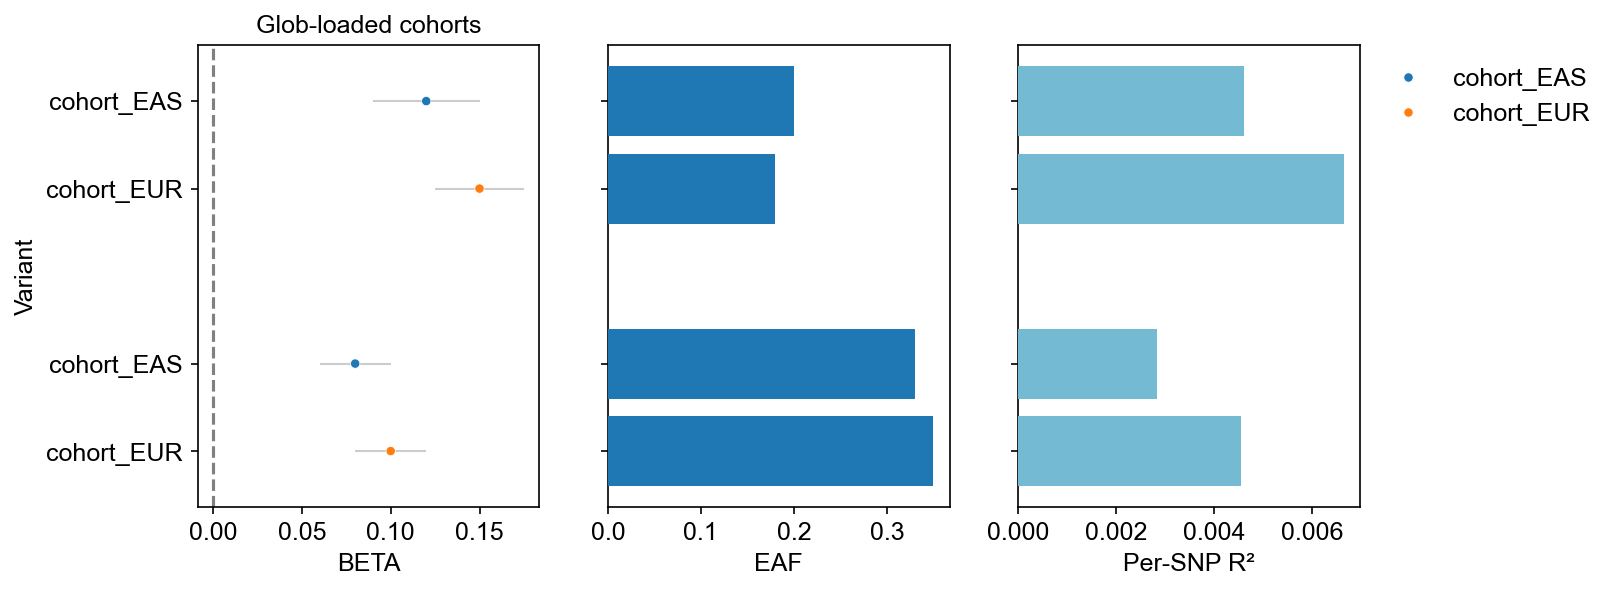

In [23]:
sset_glob.plot_effect(
    y="STUDY",
    group=["CHR", "POS"],
    y_sort=["CHR", "POS", "STUDY"],
    hue="STUDY",
    gap=1,
    title="Glob-loaded cohorts",
    eaf_panel=True,
    snpvar_panel=True,
    snpr2_label="Per-SNP R²",
    fig_kwargs={"figsize": (10, 4), "dpi": 150},
    save=os.path.join(ROOT, "docs", "images", "notebooks", "visualization_variant_set_glob.png"),
    verbose=True,
)
shutil.rmtree(tmpdir)

## Optional: real BBJ sample data

If you have downloaded sample data (`examples/0_sample_data/download_sample_data.sh`), you can load BMI female/male cohorts and compare a shared lead SNP:

```python
load_kwargs = dict(
    snpid="SNP", chrom="CHR", pos="POS", ea="ALT", nea="REF",
    beta="BETA", se="SE", p="P", build="19", verbose=False,
)
bmi_f = gl.Sumstats("../0_sample_data/bmi_female_bbj.txt.gz", **load_kwargs)
bmi_m = gl.Sumstats("../0_sample_data/bmi_male_bbj.txt.gz", **load_kwargs)

lead = bmi_f.get_lead(sig_level=5e-8, verbose=False).head(3)
variant_set = lead["SNPID"].tolist()

sset_bbj = gl.SumstatsSet({"BMI female": bmi_f, "BMI male": bmi_m}, variant_set=variant_set)
sset_bbj.get_per_snp_r2(mode="q", vary=1, verbose=False)
sset_bbj.plot_effect(y="STUDY", group=["CHR", "POS"], hue="STUDY", snpvar_panel=True)
```